## Импорт библиотек

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib_venn import venn2

from text_similarity_datasketch import compare_texts, preprocess, similarity_label


In [11]:
module_dir = Path.cwd()
if not (module_dir / "text_similarity_datasketch.py").exists():
    module_dir = Path.cwd() / "lections" / "text_similarity"

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

## Тексты и параметры

Можно менять строки, размер n-грамм и длину MinHash-сигнатуры.


In [4]:
text1 = "Машинное обучение анализирует данные и строит модели"
text2 = "Машинное обучение изучает данные и улучшает модели"

ngram_size = 1
num_perm = 128


## Сравнение текстов функцией из модуля

`compare_texts` возвращает множества n-грамм, точный коэффициент Жаккара и приближенную MinHash-оценку.


In [5]:
result = compare_texts(text1, text2, n=ngram_size, num_perm=num_perm)

print("Токены 1:", preprocess(text1))
print("Токены 2:", preprocess(text2))
print("n-граммы 1:", sorted(result.text1_ngrams))
print("n-граммы 2:", sorted(result.text2_ngrams))
print(f"Точный Жаккар: {result.exact_jaccard:.3f}")
print(f"MinHash-оценка Жаккара: {result.minhash_jaccard:.3f}")
print("Вывод:", similarity_label(result.minhash_jaccard))


Токены 1: ['машинное', 'обучение', 'анализирует', 'данные', 'и', 'строит', 'модели']
Токены 2: ['машинное', 'обучение', 'изучает', 'данные', 'и', 'улучшает', 'модели']
n-граммы 1: ['анализирует', 'данные', 'и', 'машинное', 'модели', 'обучение', 'строит']
n-граммы 2: ['данные', 'и', 'изучает', 'машинное', 'модели', 'обучение', 'улучшает']
Точный Жаккар: 0.556
MinHash-оценка Жаккара: 0.516
Вывод: тексты умеренно похожи


## Пересечение n-грамм


In [6]:
ngrams1 = result.text1_ngrams
ngrams2 = result.text2_ngrams

intersection = ngrams1 & ngrams2
only_text1 = ngrams1 - ngrams2
only_text2 = ngrams2 - ngrams1

print("Только текст 1:", sorted(only_text1))
print("Пересечение:", sorted(intersection))
print("Только текст 2:", sorted(only_text2))


Только текст 1: ['анализирует', 'строит']
Пересечение: ['данные', 'и', 'машинное', 'модели', 'обучение']
Только текст 2: ['изучает', 'улучшает']


## Визуализация множеств n-грамм


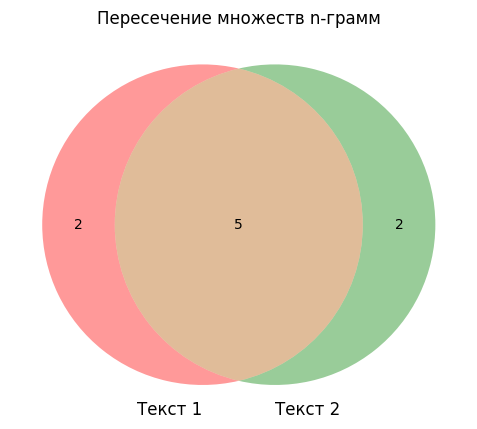

In [19]:
plt.figure(figsize=(7, 5))
venn2([ngrams1, ngrams2], set_labels=("Текст 1", "Текст 2"))
plt.title("Пересечение множеств n-грамм")
plt.show()


## Точный Жаккар vs MinHash

На графике видно, насколько оценка MinHash близка к точному коэффициенту Жаккара для выбранного `num_perm`.


In [ ]:
scores = [result.exact_jaccard, result.minhash_jaccard]
labels = ["Точный Жаккар", "MinHash"]
colors = ["#D62728", "#4C78A8"]

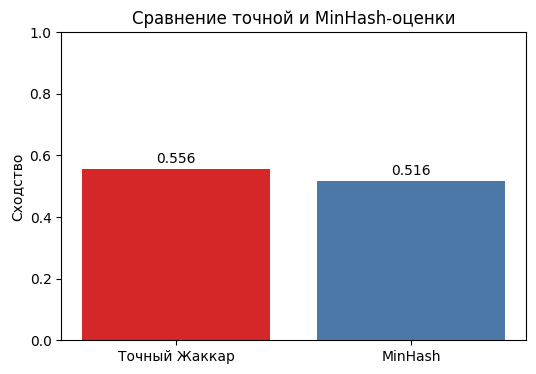

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(labels, scores, color=colors)
plt.ylim(0, 1)
plt.ylabel("Сходство")
plt.title("Сравнение точной и MinHash-оценки")

for idx, score in enumerate(scores):
    plt.text(idx, min(score + 0.02, 0.98), f"{score:.3f}", ha="center")

plt.show()

## Как `num_perm` влияет на оценку

Здесь ноутбук снова вызывает `compare_texts` из `text_similarity_datasketch.py` для разных длин сигнатуры.


In [15]:
perm_values = [16, 32, 64, 128, 256, 512]
estimates = [
    compare_texts(text1, text2, n=ngram_size, num_perm=perm).minhash_jaccard
    for perm in perm_values
]


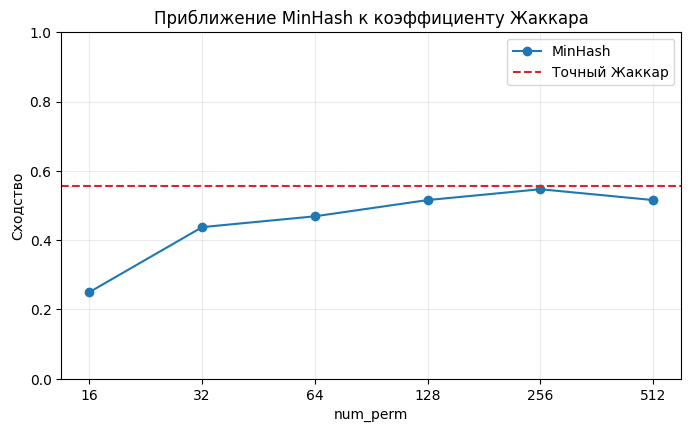

In [16]:
plt.figure(figsize=(8, 4.5))
plt.plot(perm_values, estimates, marker="o", label="MinHash")
plt.axhline(result.exact_jaccard, color="#D62728", linestyle="--", label="Точный Жаккар")
plt.xscale("log", base=2)
plt.xticks(perm_values, perm_values)
plt.ylim(0, 1)
plt.xlabel("num_perm")
plt.ylabel("Сходство")
plt.title("Приближение MinHash к коэффициенту Жаккара")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [17]:
for perm, score in zip(perm_values, estimates):
    print(f"num_perm={perm:>3}: {score:.3f}")

num_perm= 16: 0.250
num_perm= 32: 0.438
num_perm= 64: 0.469
num_perm=128: 0.516
num_perm=256: 0.547
num_perm=512: 0.516


## Итог


In [ ]:
print(f"Сходство по MinHash: {result.minhash_jaccard:.3f}")
print("Вывод:", similarity_label(result.minhash_jaccard))

Сходство по MinHash: 0.516
Вывод: тексты умеренно похожи
